# Tarea 4. Muestreo de distribuciones

<img style="float: right; margin: 0px 0px 15px 15px;" src="https://storage.needpix.com/rsynced_images/bayesian-2889576_1280.png" width="200px" height="180px" />

En esta cuarta tarea, reforzaremos el muestreo de distribuciones usando los métodos vistos en clase.

Recuerda que ante cualquier duda, me puedes contactar al correo esjimenezro@iteso.mx.

<p style="text-align:right;"> Imagen recuperada de: https://storage.needpix.com/rsynced_images/bayesian-2889576_1280.png.</p>

In [ ]:
from matplotlib import pyplot as plt
from scipy.stats import lognorm
import numpy as np

Considere la distribución de probabilidad no normalizada definida a través de la siguiente función de python:

In [78]:
def rare_pdf(x):
    return lognorm.pdf(x, loc=0, s=0.5) + lognorm.pdf(x, loc=2, s=0.3)

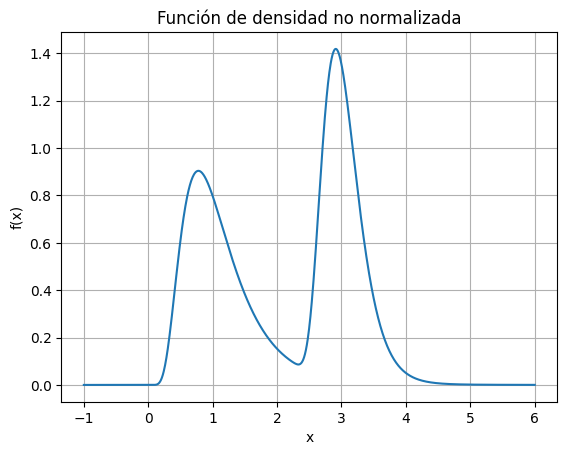

In [79]:
x = np.linspace(-1, 6, 1000)
plt.plot(x, rare_pdf(x))
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Función de densidad no normalizada')
plt.grid()

Para muestrear de esta distribución, vamos a comparar dos algoritmos de muestreo y rechazo que vimos. Implementar:

1. (40 puntos) El algoritmo de muestreo y rechazo para distribuciones univariadas. Recuerde que acá debes elegir un múltiplo escalar de una distribución normal $K \mathcal{N(x|\mu, \sigma)}$ que acote por arriba la distribución que debemos muestrear. Debe de elegir $K$ lo más justo posible para que el algoritmo no "desperdice" muchas muestras. También debe elegir $\mu$ y $\sigma$ cuidadosamente.

2. (40 puntos) El algortimo de Metrópolis-Hastings, eligiendo como distribución de muestreo $Q(x -> x') = \mathcal{N}(x'|x, \sigma^*) = \mathcal{N}(x|x', \sigma^*) = Q(x' -> x)$. Acá, debe de elegir $\sigma^*$. Un buen punto de arranque es el $\sigma$ que eligió en el punto anterior. Recuerde que una vez definida $Q$, debe construir la distribución de aceptación $A$ para el algoritmo.

En ambos casos **provea los histogramas de las muestras** contrastándolos con le función de densidad **normalizada** (para encontrarla puedes dividir la densidad no normalizada por el valor de la integral de la misma desde $-\infty$ hasta $\infty$ - puedes usar el métodos scipy.integrate.quad para hacer el cálculo numérico de la integral), para ver que todo esté funcionando correctamente.

Al generar 10000 muestras con ambos esquemas:

* (10 puntos) ¿Cuál algoritmo resultó ser más eficiente respecto a la proporción de muestras aceptadas?
* (10 puntos) ¿Por qué cree que sucedió esto?

K óptimo: 8.3716


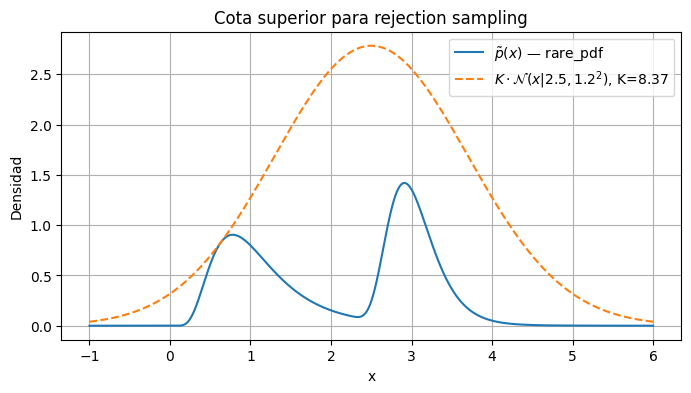

Muestras generadas:  10000
Muestras aceptadas:  2318
Tasa de aceptación:  23.18%


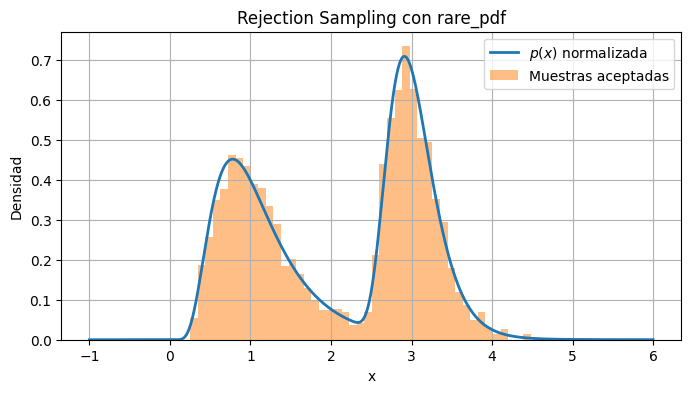

In [80]:
# 1. (40 puntos) El algoritmo de muestreo y rechazo para distribuciones univariadas. 
# Recuerde que acá debes elegir un múltiplo escalar de una distribución normal $K \mathcal{N(x|\mu, \sigma)}$ que acote por arriba la distribución que debemos muestrear. 
# Debe de elegir $K$ lo más justo posible para que el algoritmo no "desperdice" muchas muestras. También debe elegir $\mu$ y $\sigma$ cuidadosamente.

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, norm
from scipy.integrate import quad

def rare_pdf(x):
    return lognorm.pdf(x, loc=0, s=0.5) + lognorm.pdf(x, loc=2, s=0.3)

mu    = 2.5   
sigma = 1.2   
x_grid = np.linspace(-1, 6, 10000)
q_vals = norm.pdf(x_grid, loc=mu, scale=sigma)   # N(x | mu, sigma)
p_vals = rare_pdf(x_grid)

# Calculamos K como el máximo de p(x) / q(x)
K = np.max(p_vals / q_vals)
print(f"K óptimo: {K:.4f}")

# Visualización de la normalización y la cota superior
plt.figure(figsize=(8, 4))
plt.plot(x_grid, p_vals,          label=r'$\tilde{p}(x)$ — rare_pdf')
plt.plot(x_grid, K * q_vals, '--', label=rf'$K \cdot \mathcal{{N}}(x|{mu}, {sigma}^2)$, K={K:.2f}')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.title('Cota superior para rejection sampling')
plt.legend()
plt.grid()
plt.show()

# Algoritmo de muestreo y rechazo
n_samples = 10000

# Muestreos de la distribución propuesta
x_tilde = norm.rvs(loc=mu, scale=sigma, size=n_samples)
u = np.random.uniform(low=0, high=K * norm.pdf(x_tilde, loc=mu, scale=sigma))
x_accepted = x_tilde[u < rare_pdf(x_tilde)]

tasa_aceptacion = len(x_accepted) / n_samples
print(f"Muestras generadas:  {n_samples}")
print(f"Muestras aceptadas:  {len(x_accepted)}")
print(f"Tasa de aceptación:  {tasa_aceptacion:.2%}")

Z, _ = quad(rare_pdf, -1, 10) 
normalized_pdf = lambda x: rare_pdf(x) / Z

plt.figure(figsize=(8, 4))
plt.plot(x_grid, normalized_pdf(x_grid), label=r'$p(x)$ normalizada', linewidth=2)
plt.hist(x_accepted, bins=50, density=True, alpha=0.5, label='Muestras aceptadas')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.title('Rejection Sampling con rare_pdf')
plt.legend()
plt.grid()
plt.show()

Muestras generadas:  10000
Muestras aceptadas:  4543
Tasa de aceptación:  45.43%


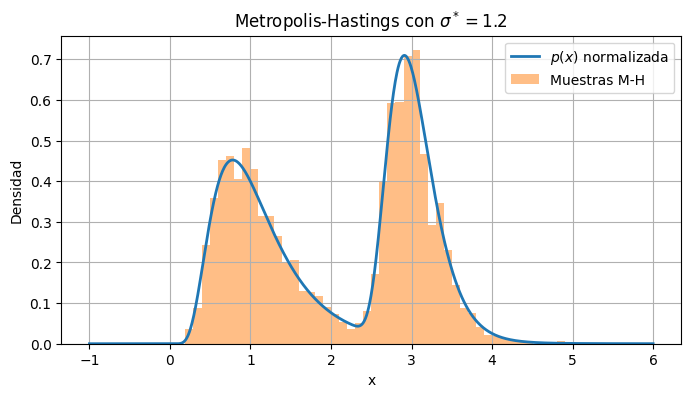

In [81]:
# 2. (40 puntos) El algortimo de Metrópolis-Hastings, eligiendo como distribución de muestreo $Q(x -> x') = \mathcal{N}(x'|x, \sigma^*) = \mathcal{N}(x|x', \sigma^*) = Q(x' -> x)$. 
# Acá, debe de elegir $\sigma^*$. Un buen punto de arranque es el $\sigma$ que eligió en el punto anterior. Recuerde que una vez definida $Q$, debe construir la distribución de aceptación $A$ para el algoritmo.

from scipy.stats import norm, bernoulli
from scipy.integrate import quad

# Algoritmo de Metropolis-Hastings
def metropolis_hastings(x0, n_samples, sigma):
    xs = np.zeros(n_samples + 1)
    xs[0] = x0
    n_accepted = 0

    for k in range(n_samples):
        xk = xs[k]

        # Propuesta: x' ~ N(x_k, sigma*)
        x_prime = norm.rvs(loc=xk, scale=sigma)

        # Probabilidad de aceptación A
        p_actual   = rare_pdf(xk)
        p_propuesta = rare_pdf(x_prime)

        A = min(1, p_propuesta / p_actual)

        # Aceptar o rechazar
        if bernoulli.rvs(A):
            xs[k + 1] = x_prime
            n_accepted += 1
        else:
            xs[k + 1] = xk

    return xs, n_accepted

sigma_n = 1.2
x0       = 2.5   
n_samples = 10000
mh_samples, n_accepted = metropolis_hastings(x0, n_samples, sigma_n)

print(f"Muestras generadas:  {n_samples}")
print(f"Muestras aceptadas:  {n_accepted}")
print(f"Tasa de aceptación:  {n_accepted / n_samples:.2%}")

# Descartamos las primeras muestras (burn-in) para quedarnos solo con las que ya convergen a la distribución objetivo
burn_in     = 1000
mh_final    = mh_samples[burn_in:]

# Visualizaciones
Z, _ = quad(rare_pdf, 0, np.inf)
normalized_pdf = lambda x: rare_pdf(x) / Z

x_grid = np.linspace(-1, 6, 1000)

plt.figure(figsize=(8, 4))
plt.plot(x_grid, normalized_pdf(x_grid), label=r'$p(x)$ normalizada', linewidth=2)
plt.hist(mh_final, bins=50, density=True, alpha=0.5, label='Muestras M-H')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.title(f'Metropolis-Hastings con $\\sigma^*={sigma_n}$')
plt.legend()
plt.grid()
plt.show()



# Comparación de Algoritmos

Al generar 10,000 muestras con ambos esquemas obtuvimos:

| Algoritmo  | Tasa de aceptación |
|---|---|
| Rejection Sampling | 23-25% |
| Metropolis-Hastings | 44-46% |

### ¿Cuál resultó más eficiente?  
Metropolis-Hastings fue casi el doble de eficiente, aceptando 46% de las muestras en comparación al 24% del Rejection Sampling.

### ¿Por qué cree que sucedió esto?
En el Rejection Sampling, la distribución propuesta de K * N debe cubrir toda la distribución objetivo por arriba en todos los puntos, lo que inevitablemente genera una cota holgada en zonas de baja densidad como por ejemplo, entre los dos picos o en las colas, desperdiciando muestras cuando hace esto. Pero por otro lado, Metropolis-Hastings propone el siguiente punto siempre cerca del punto actual, por lo que casi siempre propone valores en zonas de densidad similar o mayor y por eso es que se aceptan más muestras. 


<script>
  $(document).ready(function(){
    $('div.prompt').hide();
    $('div.back-to-top').hide();
    $('nav#menubar').hide();
    $('.breadcrumb').hide();
    $('.hidden-print').hide();
  });
</script>

<footer id="attribution" style="float:right; color:#808080; background:#fff;">
Created with Jupyter by Esteban Jiménez Rodríguez.
</footer>